# Edit Operators

In [167]:
import cv_depot.api as cvd

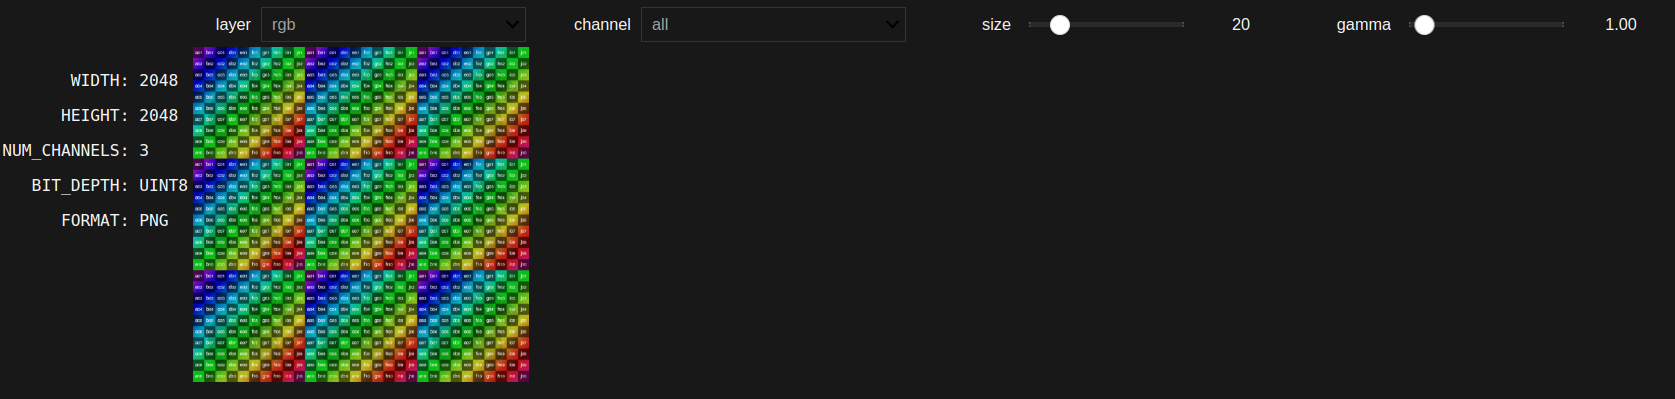

In [273]:
def view(image):
    chan = image.channels
    if image.num_channels > 1:
        chan = 'rgb'        
    cvd.ImageViewer(image[:, :, chan], size=20).show()

src = '/home/ubuntu/images/misc/uv-checker.png'
large_image = cvd.Image.read(src)

view(large_image)

<font color="#EBB483">**crop** crops an image according to width and height multipliers.

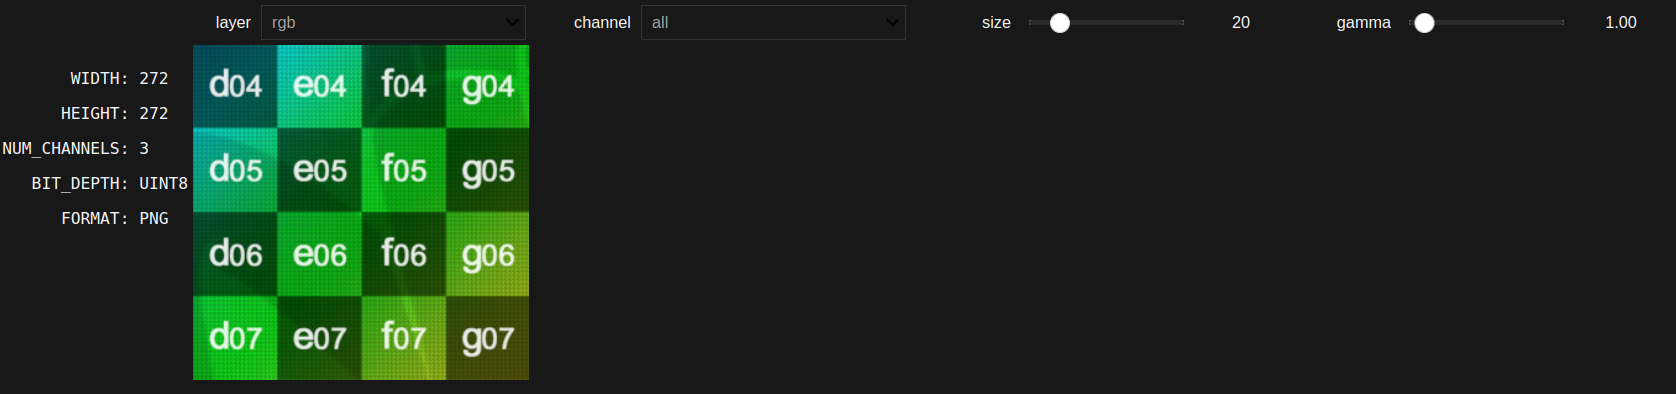

In [274]:
m = 0.1328125
image = cvd.ops.edit.crop(large_image, m, m)
view(image)

<font color="#EBB483">**get_warp_matrix** creates a warp matrix.

In [271]:
warp = cvd.ops.edit.get_warp_matrix(angle=45, translate_x=120)
warp

array([[  0.70710678,  -0.70710678, 120.        ],
       [  0.70710678,   0.70710678,   0.        ],
       [  0.        ,   0.        ,   1.        ]])

<font color="#EBB483">**warp** warps an image given a warp matrix or warp matrix parameters.

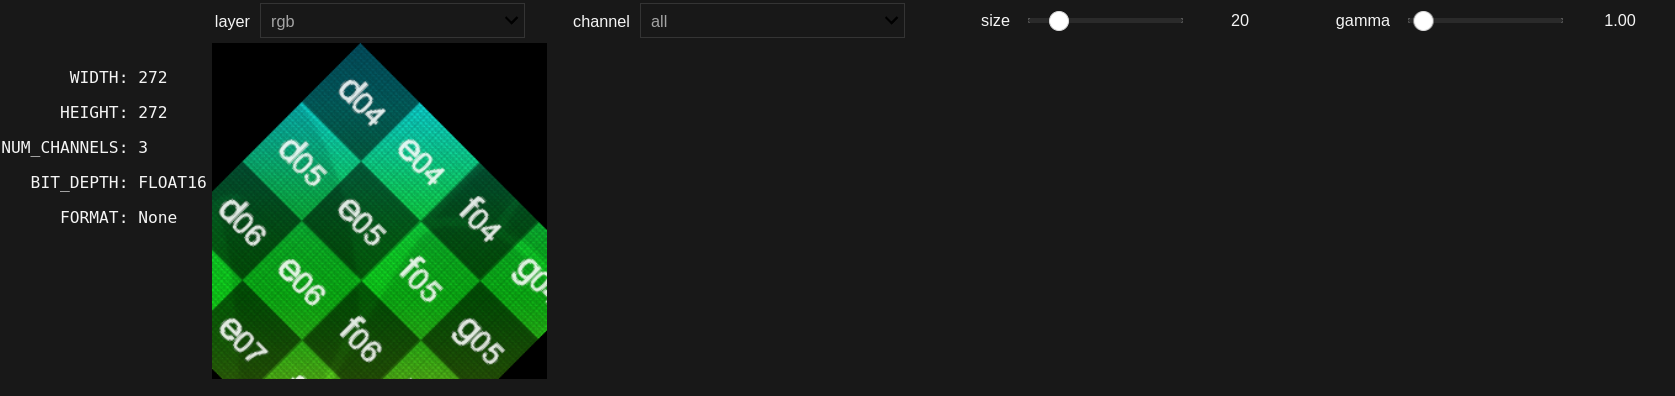

In [275]:
warped = cvd.ops.edit.warp(image, matrix=warp)
view(warped)

<font color="#EBB483">**pad** pads an image according to an anchor point.

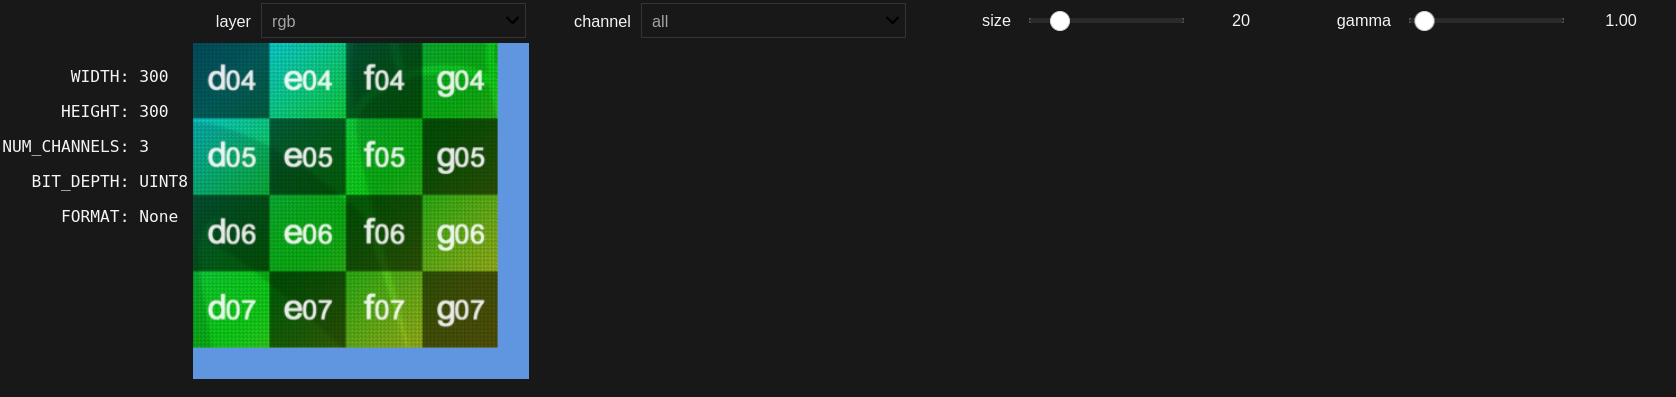

In [276]:
pad = cvd.ops.edit.pad(
    image,
    shape=(300, 300, 3),
    anchor=cvd.Anchor.TOP_LEFT,
    color=cvd.BasicColor.BLUE1,
)
view(pad)

<font color="#EBB483">**reformat** formats an image to a given width and height scale factors.

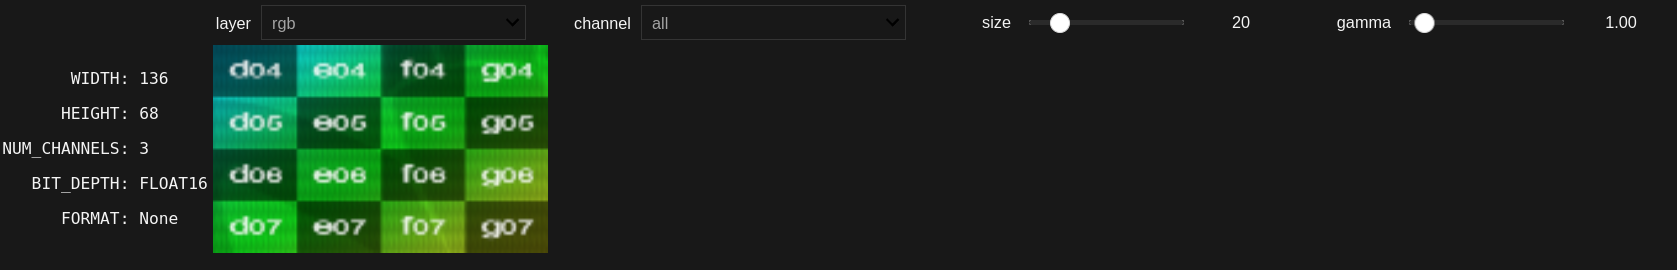

In [277]:
small = cvd.ops.edit.reformat(image, width=0.5, height=0.25)
view(small)

<font color="#EBB483">**staple** combines two images into a single image, given a direction.

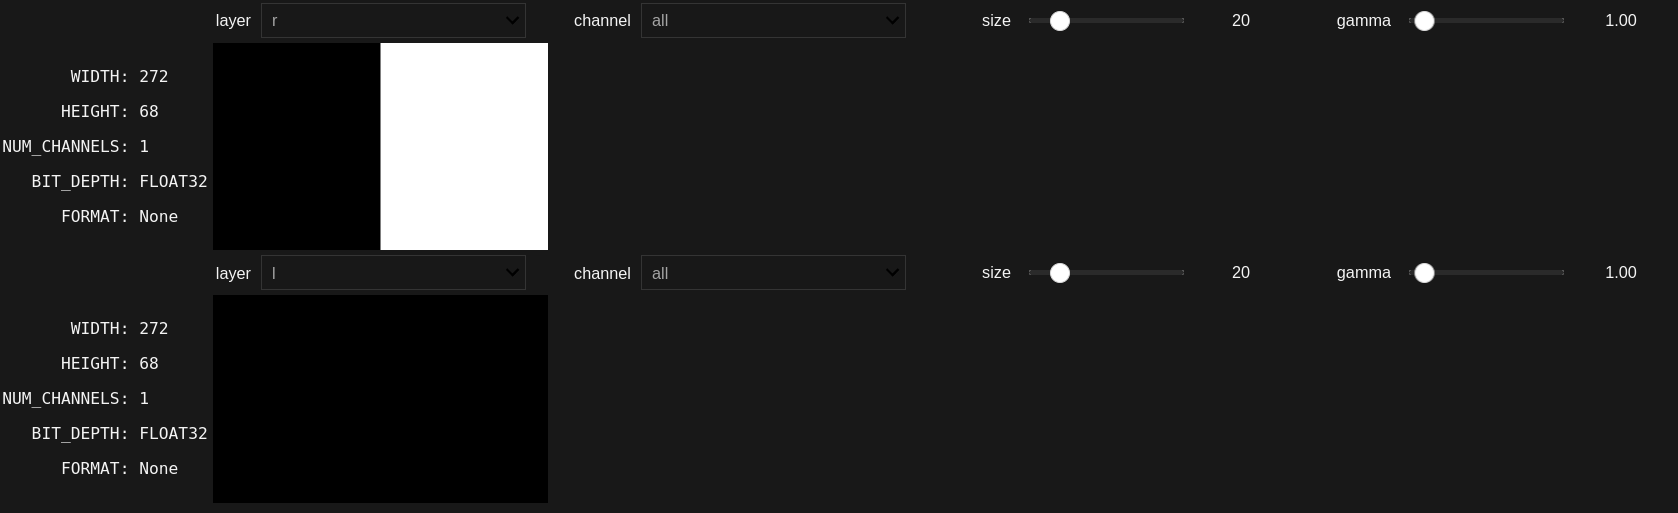

In [279]:
w = int(image.width / 2)
h = int(image.height / 4)
block = cvd.ops.draw.checkerboard(2, 1, (w, h))[:, :, 'r']
view(block)
sep = cvd.ops.draw.swatch((w * 2, h, 1), cvd.BasicColor.BLACK)
view(sep)

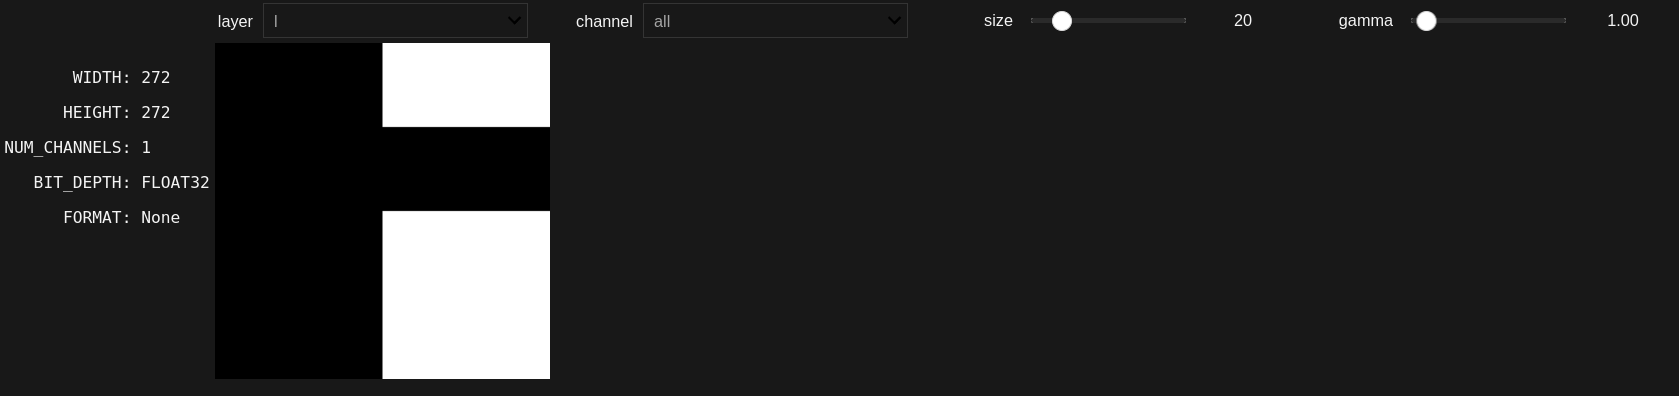

In [280]:
mask = cvd.ops.edit.staple(block, sep, direction='below')
mask = cvd.ops.edit.staple(mask, block, direction='below')
mask = cvd.ops.edit.staple(mask, block, direction='below')
view(mask)

<font color="#EBB483">**cut** splits an image according to indices along a given axis.

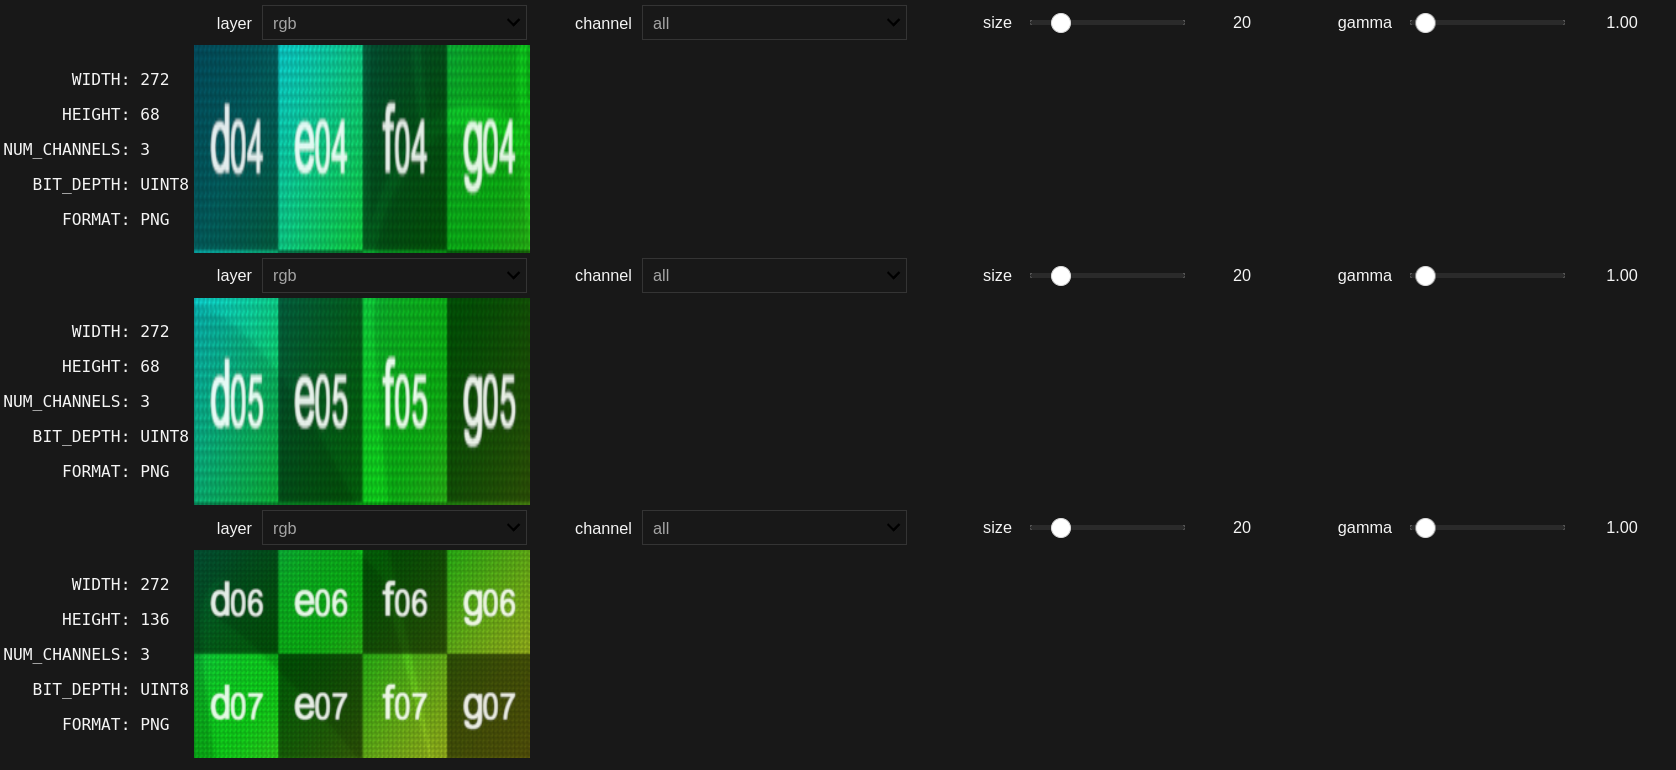

In [281]:
a, b, c = cvd.ops.edit.cut(image, [0, 68, 136], axis='horizontal')
view(a)
view(b)
view(c)

<font color="#EBB483">**chop** splits an image into mulitple image according to a mask channel.

<font color="#EBB483">It returns a dictionary with coordinate keys in accordance with a given mode.

<font color="#EBB483">In this case the image was first split vertically and then each part was split horizontally.

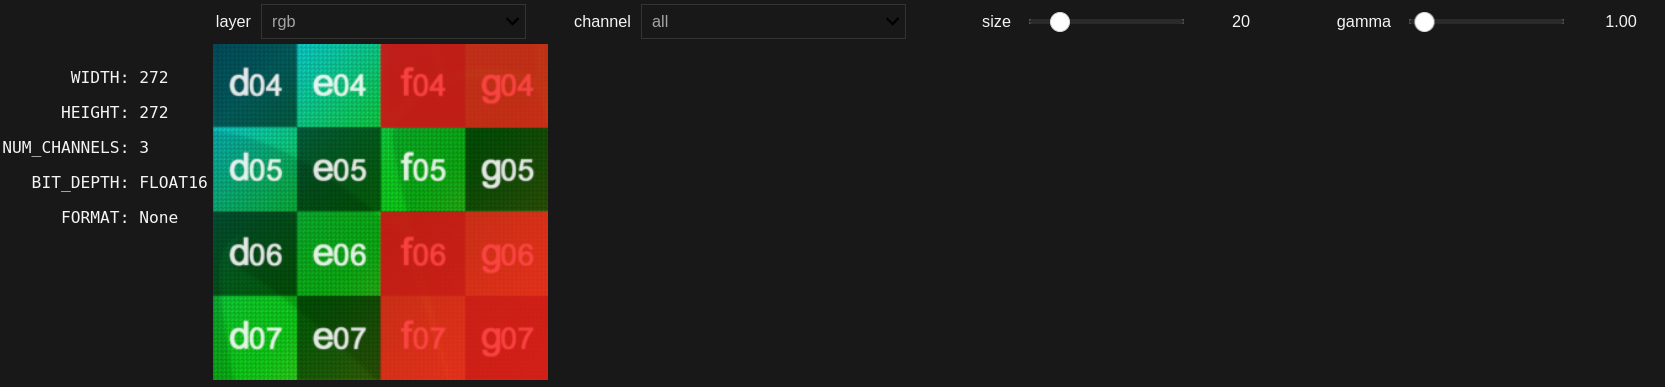

In [283]:
cmap = cvd.ChannelMap({
    'r': '0.r',
    'g': '0.g',
    'b': '0.b',
    'a': '1.l',
})
image = cvd.ops.channel.remap([image, mask], cmap).to_bit_depth(cvd.BitDepth.FLOAT16)
x = cvd.ops.draw.highlight(image, color='RED', opacity=0.75)[:, :, 'rgb']
view(x)

In [ ]:
parts = cvd.ops.edit.chop(image, channel='a', mode='vertical-horizontal')
parts

{(0, 0): <cv_depot.core.image.Image at 0x7f92e86bc880>,
 (1, 2): <cv_depot.core.image.Image at 0x7f92e86bf670>,
 (1, 1): <cv_depot.core.image.Image at 0x7f92e86bd3c0>,
 (1, 0): <cv_depot.core.image.Image at 0x7f92e86bc9a0>}

<font color="#EBB483">The left chunk of the image.

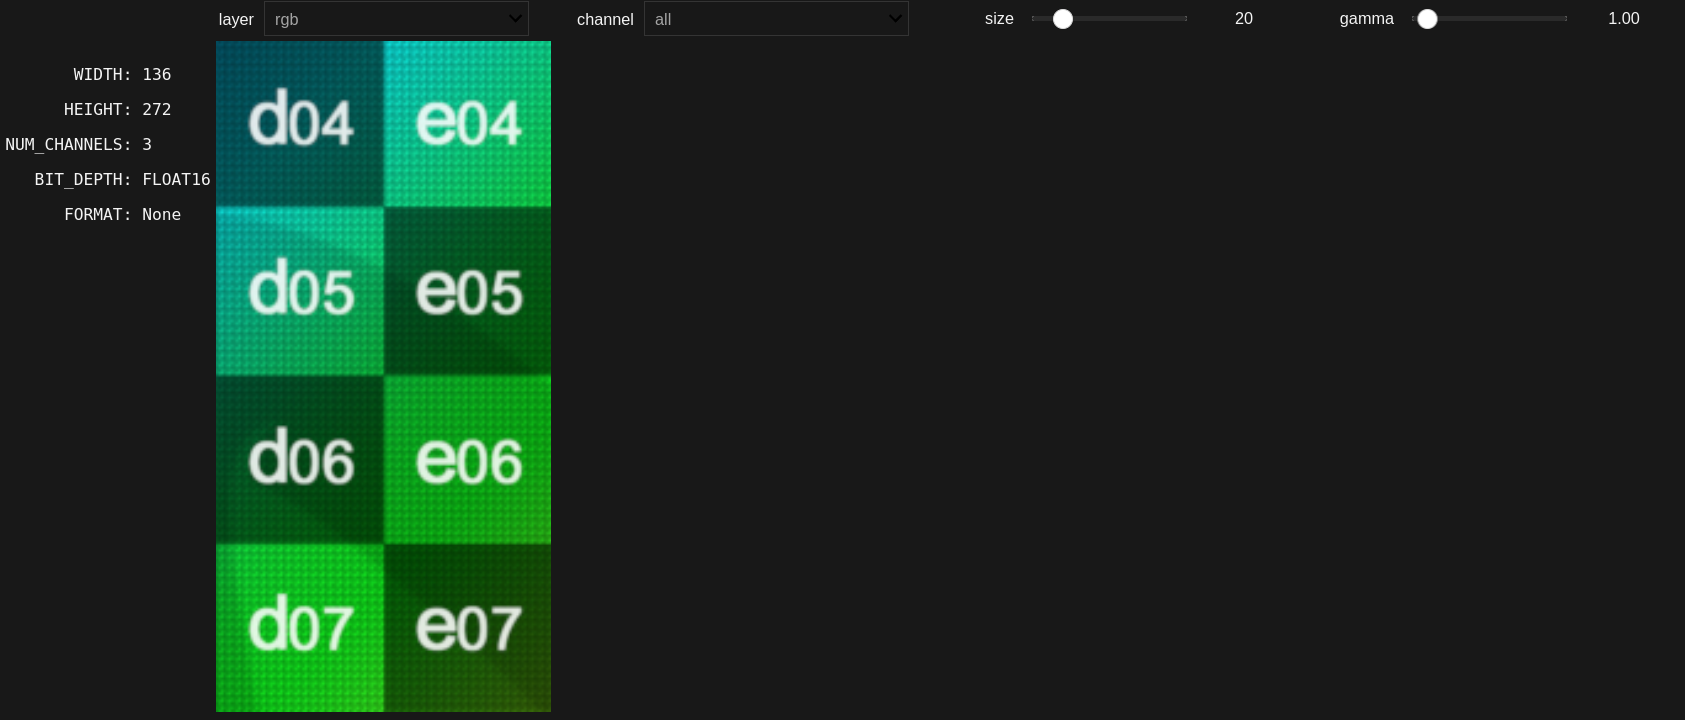

In [284]:
x = parts[(0, 0)][:, :, 'rgb']
view(x)

<font color="#EBB483">The first part of the right chunk of the image.

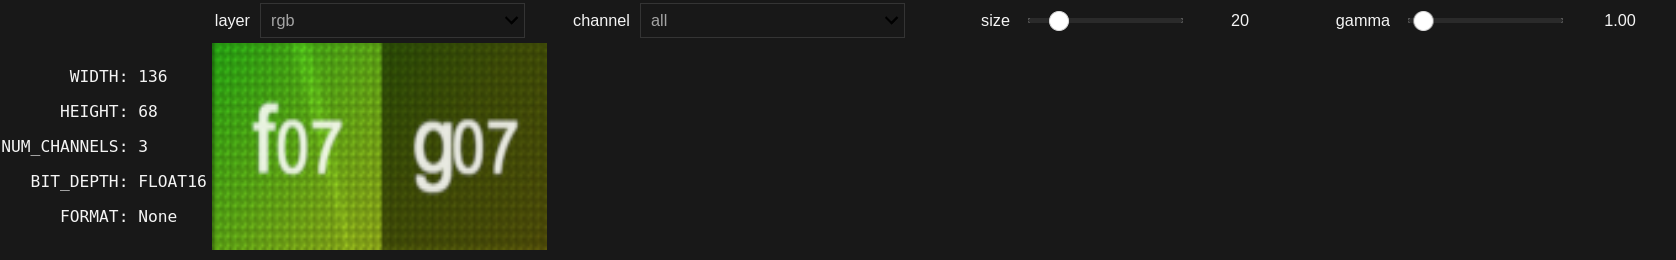

In [285]:
x = parts[(1, 0)][:, :, 'rgb']
view(x)